# Projet Data Mining Analyse de données médicales

## I. Prétraitement des données : Breast Cancer Wisconsin Dataset

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Chargement du CSV
df = pd.read_csv('data/diabetes.csv')

### Nettoyage des données manquantes et doublons

In [3]:
cols_avec_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_avec_zeros:
    df[col] = df[col].replace(0, np.nan)

# Remplissage par la médiane
df.fillna(df.median(), inplace=True)

# Suppression des doublons existants
df.drop_duplicates(inplace=True)
print(f"Nombre de lignes après nettoyage : {len(df)}")

Nombre de lignes après nettoyage : 768


Nous avons identifié des valeurs nulles aberrantes dans des colonnes comme l'insuline et l'IMC. Couper par la médiane permet de conserver la taille du dataset sans introduire d'erreurs.

### Encodage et Standardisation

In [4]:
from sklearn.calibration import LabelEncoder

# Encodage de la variable cible 'Outcome'
le = LabelEncoder()
df['Outcome'] = le.fit_transform(df['Outcome'])

# Standardisation des données
scaler = StandardScaler()
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

En ramenant les données à une moyenne de 0 et un écart-type de 1, nous garantissons que le modèle KNN ne privilégie pas une variable simplement parce que ses chiffres sont plus grands.

### Analyse exploratoire avec graphiques

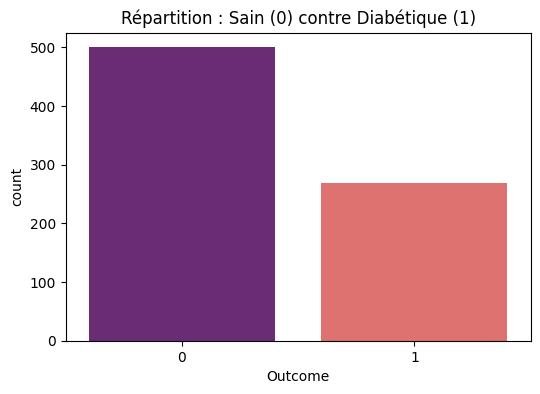

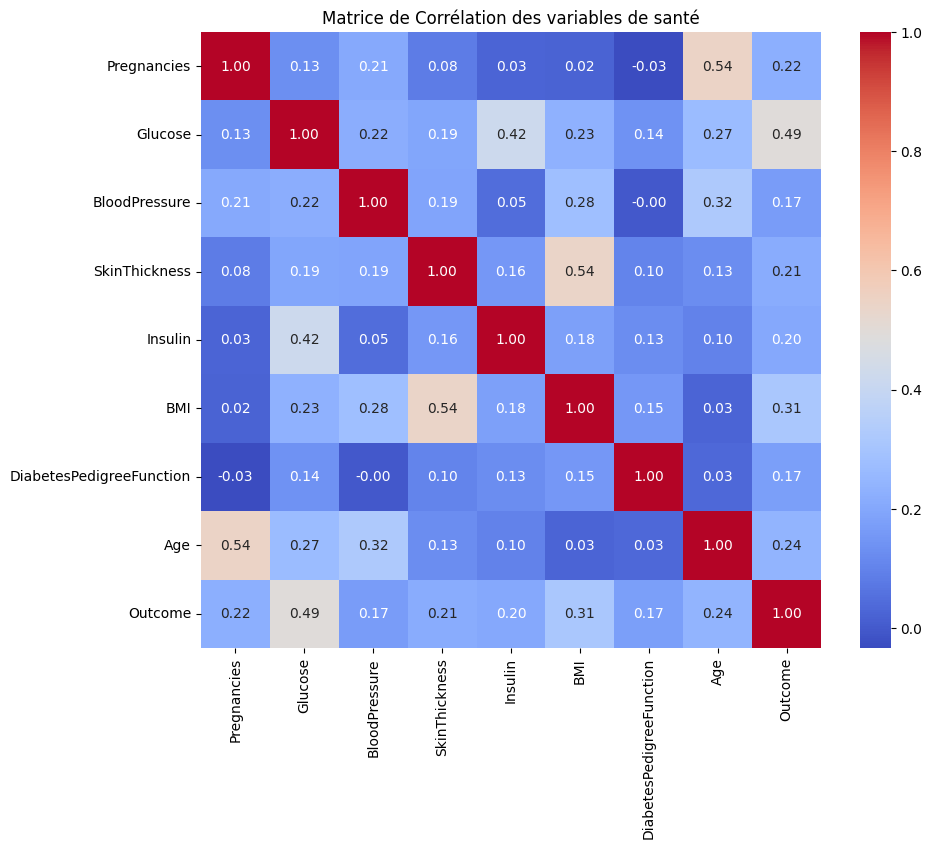

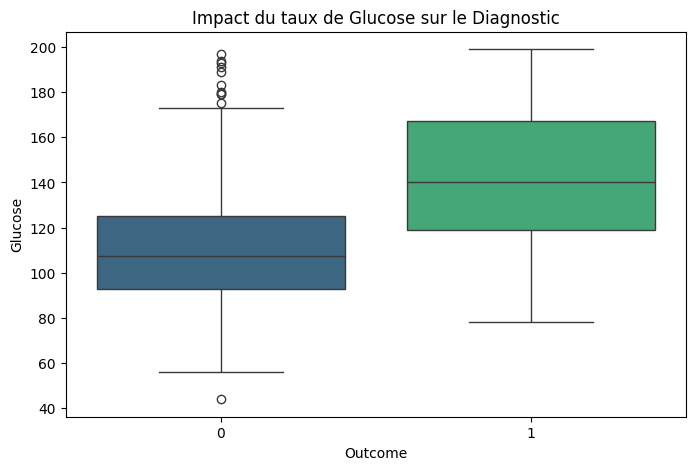

In [5]:
# Répartition des classes
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome', hue='Outcome', palette='magma', legend=False)
plt.title("Répartition : Sain (0) contre Diabétique (1)")
plt.show()

# Matrice de corrélation
plt.figure(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation des variables de santé")
plt.show()

# Analyse de la distribution
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Outcome', y='Glucose', hue='Outcome', palette='viridis', legend=False)
plt.title("Impact du taux de Glucose sur le Diagnostic")
plt.show()

La matrice de corrélation montre que le Glucose et l'IMC ont la plus forte corrélation positive avec le diabète, ce qui confirme la pertinence des attributs choisis.

# II. Règles d’association

### Application d’Apriori - Extraction de règles

In [6]:
from mlxtend.frequent_patterns import apriori, association_rules

# Création du DataFrame, si la valeur est > médiane, on considère l'attribut comme élevé
df_assoc = pd.DataFrame()

for col in df.columns:
    if col != 'Outcome':
        df_assoc[col + '_High'] = df[col] > df[col].median()
    else:
        df_assoc['Diabetes_Positive'] = df['Outcome'] == 1

print(df_assoc.head())

   Pregnancies_High  Glucose_High  BloodPressure_High  SkinThickness_High  \
0              True          True               False                True   
1             False         False               False               False   
2              True          True               False               False   
3             False         False               False               False   
4             False          True               False                True   

   Insulin_High  BMI_High  DiabetesPedigreeFunction_High  Age_High  \
0         False      True                           True      True   
1         False     False                          False      True   
2         False     False                           True      True   
3         False     False                          False     False   
4          True      True                           True      True   

   Diabetes_Positive  
0               True  
1              False  
2               True  
3              False  
4

### Support (A → B)

In [7]:
# Support(A → B) = (Transactions contenant A ∪ B) / (Nombre total de transactions)
frequent_itemsets = apriori(df_assoc, min_support=0.1, use_colnames=True)

print("Nombre d'itemsets fréquents trouvés :", len(frequent_itemsets))
print(frequent_itemsets.sort_values(by='support', ascending=False).head())

Nombre d'itemsets fréquents trouvés : 115
    support                                    itemsets
6  0.500000  frozenset({DiabetesPedigreeFunction_High})
5  0.490885                       frozenset({BMI_High})
1  0.490885                   frozenset({Glucose_High})
7  0.484375                       frozenset({Age_High})
2  0.454427             frozenset({BloodPressure_High})


Le support indique la fréquence à laquelle la combinaison de symptômes apparaît dans l'ensemble du dataset. Par exemple un support de 0.1 signifie que 10% des patients partagent ces caractéristiques.

### Confiance (A → B)

In [8]:
# Confiance(A → B) = Support(A ∪ B) / Support(A)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

print(f"Total de règles générées : {len(rules)}")

Total de règles générées : 600


La confiance mesure la fiabilité de la règle. Par exemple si la confiance est de 0.7, cela signifie que dans 70% des cas où le patient a un Glucose élevé, il est également testé positif au diabète.

### Antécédents médicaux → Diagnostic

In [9]:
# On filtrepour trouver les règles menant au diagnostic diabète positif
indices_diabete = []

for index, row in rules.iterrows():
    if 'Diabetes_Positive' in row['consequents']:
        indices_diabete.append(index)

diabetes_rules = rules.loc[indices_diabete]

# On trie par Lift pour voir les associations les plus fortes
diabetes_rules = diabetes_rules.sort_values(by='lift', ascending=False)

# Résultats avec les métriques 
print("Top 10 des règles d'association pour le Diabète :")
colonnes_affichage = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(diabetes_rules[colonnes_affichage].head(10))

Top 10 des règles d'association pour le Diabète :
                                           antecedents  \
437                frozenset({Glucose_High, Age_High})   
438        frozenset({Glucose_High, Pregnancies_High})   
495                    frozenset({BMI_High, Age_High})   
574      frozenset({Glucose_High, BMI_High, Age_High})   
507  frozenset({DiabetesPedigreeFunction_High, Age_...   
549                frozenset({Glucose_High, Age_High})   
496            frozenset({BMI_High, Pregnancies_High})   
508  frozenset({DiabetesPedigreeFunction_High, Preg...   
587  frozenset({DiabetesPedigreeFunction_High, Gluc...   
535                frozenset({Glucose_High, BMI_High})   

                                           consequents   support  confidence  \
437   frozenset({Diabetes_Positive, Pregnancies_High})  0.128906    0.443946   
438           frozenset({Diabetes_Positive, Age_High})  0.128906    0.515625   
495   frozenset({Diabetes_Positive, Pregnancies_High})  0.109375    0.4

- Si Lift > 1, il existe une corrélation positive forte entre les symptômes et le diabète.
- Si Lift = 1, les deux événements sont indépendants.

## III. Classification supervisée

### Préparation des données

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Séparation des données avec 80% pour l'entraînement et 20% pour le test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Dictionnaire pour stocker les scores finaux
final_scores = {}

### Algorithme Decision Tree

In [11]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

final_scores["Decision Tree"] = {
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1-score": f1_score(y_test, y_pred_dt)
}

### Algorithme Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

final_scores["Random Forest"] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-score": f1_score(y_test, y_pred_rf)
}

### Algorithme K-Nearest Neighbors

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

final_scores["KNN"] = {
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1-score": f1_score(y_test, y_pred_knn)
}

### Algorithme AdaBoost

In [15]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

final_scores["AdaBoost"] = {
    "Accuracy": accuracy_score(y_test, y_pred_ada),
    "Precision": precision_score(y_test, y_pred_ada),
    "Recall": recall_score(y_test, y_pred_ada),
    "F1-score": f1_score(y_test, y_pred_ada)
}

### Visualisation des différents résultats

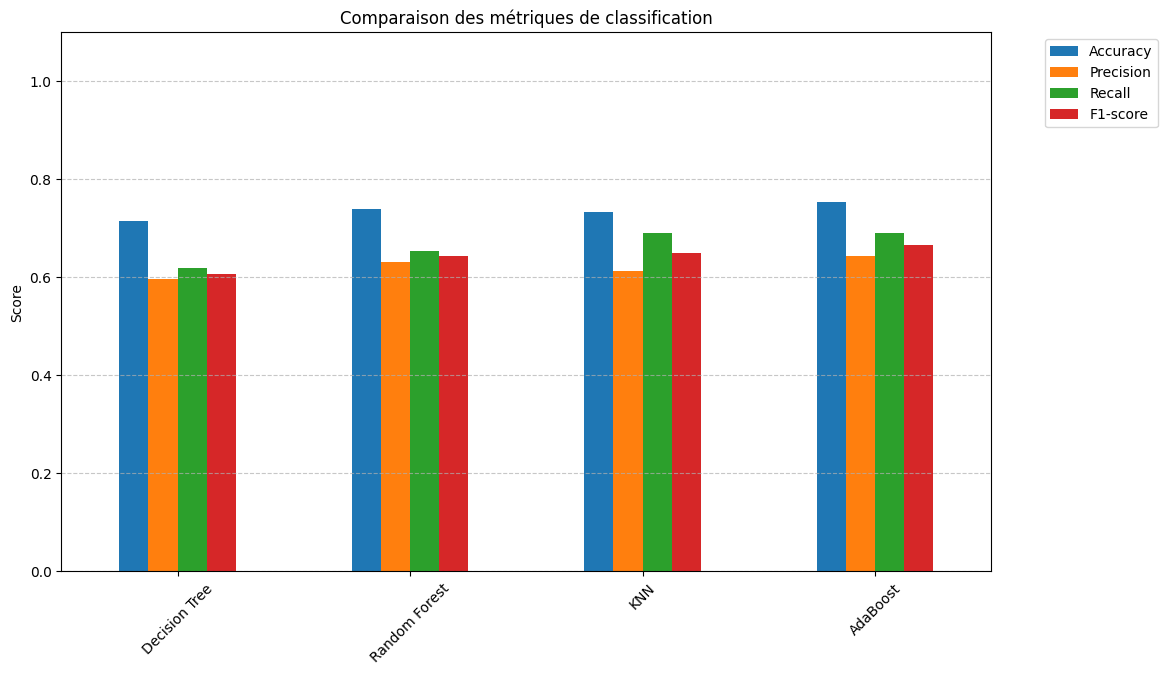

               Accuracy  Precision    Recall  F1-score
Decision Tree  0.714286   0.596491  0.618182  0.607143
Random Forest  0.740260   0.631579  0.654545  0.642857
KNN            0.733766   0.612903  0.690909  0.649573
AdaBoost       0.753247   0.644068  0.690909  0.666667


In [16]:
# Conversion en DataFrame pour l'affichage
df_results = pd.DataFrame(final_scores).T

# Création du graphique
df_results.plot(kind='bar', figsize=(12, 7))
plt.title("Comparaison des métriques de classification")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(df_results)